In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


In [2]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0.0, 0.0]
b_coeffs = [2,0.,0., 0.004]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
#expansion.plot_components()
# plt.xlabel('s')
# plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


Scalar potential phi(x,y,s): -0.000666666666666667*x*y**3 + y*(0.004*x**3 + 12)/6
Scalar potential phi at (0.4,0.2,0.5): 0.40000640000000004


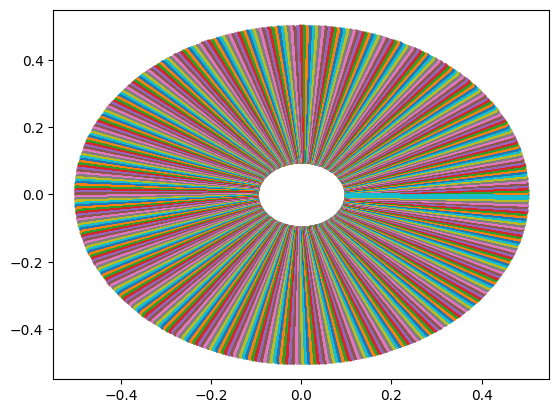

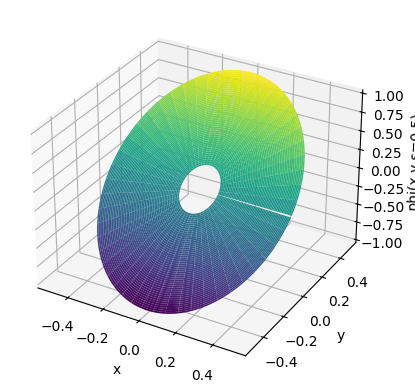

In [3]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
# npoints=201
# xa= np.linspace(-1,1,npoints) 
# ya=np.linspace(-1,1,npoints)
rmin, rmax, nr = 0.1, 0.5, 400
ntheta = 450
rr = np.linspace(rmin, rmax, nr)
tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-1,1, 40)
rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
#make a 3d plot of phi as a function of x and y for a fixed s
plt.plot(xarr[:,:,0], yarr[:,:,0], 'o', markersize=2, label='(x,y) points')

P = phi_func(xarr[:,:,0], yarr[:,:,0], 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xarr[:,:,0], yarr[:,:,0], P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [4]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
#X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)

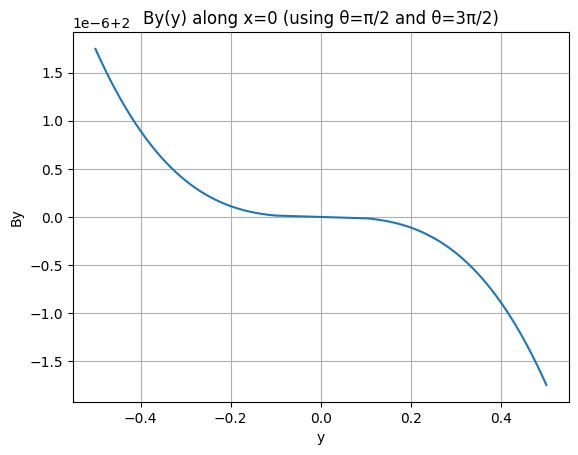

In [5]:
islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
By_pos = By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
By_neg = By_ana[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
By_all = np.concatenate([By_neg, By_pos])

order = np.argsort(y_all)
y_all = y_all[order]
By_all = By_all[order]

plt.plot(y_all, By_all)
plt.xlabel("y")
plt.ylabel("By")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")
plt.grid(True)


In [6]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)
Ax_ana = Ax(xarr, yarr, sarr)
Ay_ana = Ay(xarr, yarr, sarr)
As_ana = As(xarr, yarr, sarr)


In [7]:
#then take the curl of A from finite differences and compare with the original B field
def curl_cylindrical_from_cartesian(Ax, Ay, Az, rarr, tarr, sarr):
    """
    Compute curl(A) on a cylindrical grid (r, theta, s),
    where A is given in Cartesian components (Ax, Ay, Az).
    """

    # ---------------------------------------------------------
    # 1. Extract axes and spacings
    # ---------------------------------------------------------
    r_axis     = rarr[:,0,0]
    theta_axis = tarr[0,:,0]
    s_axis     = sarr[0,0,:]

    dr     = r_axis[1]     - r_axis[0]
    dtheta = theta_axis[1] - theta_axis[0]
    ds     = s_axis[1]     - s_axis[0]

    # ---------------------------------------------------------
    # 2. Convert A from Cartesian → cylindrical components
    # ---------------------------------------------------------
    cos_t = np.cos(tarr)
    sin_t = np.sin(tarr)

    Ar     =  Ax*cos_t + Ay*sin_t
    Atheta = -Ax*sin_t + Ay*cos_t
    Az_cyl =  Az

    # ---------------------------------------------------------
    # 3. Compute partial derivatives
    # ---------------------------------------------------------
    dAr_dtheta     = np.gradient(Ar,     dtheta, axis=1)
    dAtheta_dtheta = np.gradient(Atheta, dtheta, axis=1)
    dAz_dtheta     = np.gradient(Az_cyl, dtheta, axis=1)

    dAr_dr     = np.gradient(Ar,     dr, axis=0)
    dAtheta_dr = np.gradient(Atheta, dr, axis=0)
    dAz_dr     = np.gradient(Az_cyl, dr, axis=0)

    dAr_ds     = np.gradient(Ar,     ds, axis=2)
    dAtheta_ds = np.gradient(Atheta, ds, axis=2)
    dAz_ds     = np.gradient(Az_cyl, ds, axis=2)

    # ---------------------------------------------------------
    # 4. Curl in cylindrical coordinates
    # ---------------------------------------------------------
    r = rarr

    curl_r = (1/r) * dAz_dtheta - dAtheta_ds
    curl_theta = dAr_ds - dAz_dr

    rAtheta = r * Atheta
    d_rAtheta_dr = np.gradient(rAtheta, dr, axis=0)

    curl_z = (1/r) * d_rAtheta_dr - (1/r) * dAr_dtheta

    # ---------------------------------------------------------
    # 5. Convert curl back to Cartesian components
    # ---------------------------------------------------------
    curl_x = curl_r*cos_t - curl_theta*sin_t
    curl_y = curl_r*sin_t + curl_theta*cos_t
    curl_s = curl_z

    return curl_x, curl_y, curl_s

curl_x, curl_y, curl_s = curl_cylindrical_from_cartesian(Ax_ana, Ay_ana, As_ana, rarr, tarr, sarr)
#print(curl_Ax.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_x - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_y - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_s - Bs_ana)))


Max difference in Bx: 0.01396473367760871
Max relative difference in By: 9.74691958799193e-05
Max difference in Bs: 0.0


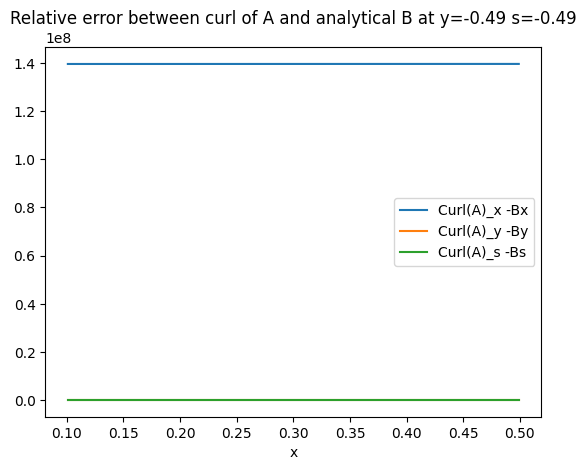

In [8]:
npoints=len(xarr)
truncatedxarr=xarr[1:npoints-1,0,10]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=(slice(1,npoints-1), 0, 10)#all x, y=0, s=0.5

plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/(1e-10+Bx_ana[position]), label='Curl(A)_x -Bx')
plt.plot(truncatedxarr, (curl_y[position]-By_ana[position])/(1e-10+By_ana[position]), label='Curl(A)_y -By')
plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/(Bs_ana[position]+1e-10), label='Curl(A)_s -Bs')

#plt.ylim((np.min((curl_Ay[position]-By_ana[position])/By_ana[position]), np.max((curl_Ay[position]-By_ana[position])/By_ana[position])))
plt.legend()
plt.title('Relative error between curl of A and analytical B at y='+str(np.round(sarr[position][1],2)) +" s="+str(np.round(sarr[position][2],2)))
plt.xlabel('x')
plt.show()


Text(0.5, 0, 'x')

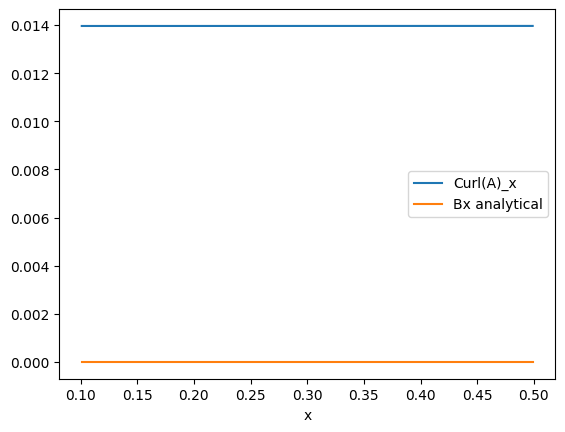

In [9]:
plt.plot(truncatedxarr, curl_x[position], label='Curl(A)_x')
plt.plot(truncatedxarr,Bx_ana[position], label='Bx analytical')
plt.legend()
plt.xlabel('x')

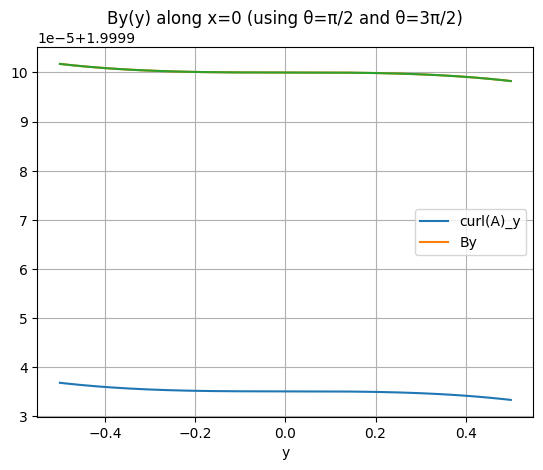

In [ ]:

islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
curly_pos = curl_y[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
curly_neg = curl_y[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
curly_all = np.concatenate([curly_neg, curly_pos])
order = np.argsort(y_all)
y_all = y_all[order]
curly_all = curly_all[order]

plt.plot(y_all, curly_all, label='curl(A)_y')
plt.plot(y_all, By_all, label='By')
plt.xlabel("y")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")
plt.plot(y_all, By_all)
plt.legend()
plt.grid(True)


In [15]:
print(0.2+30*(0.4/400))
print(rr[1]-rr[0])
print(rr[650:700])

0.23
0.0010025062656641576
[]


In [17]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    curl_x.ravel(),
    curl_y.ravel(),
    curl_s.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed,rmin=0.2,rmax=0.23,nr=30, radius=0.0015 )
bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn(0): ",bn )
print("Original bn(0): ", b_coeffs)
print("recovered an(0): ", an )
print("Original an(0): ", a_coeffs)

recovered bn(0):  [0. 0. 0. 0.]
Original bn(0):  [2, 0.0, 0.0, 0.004]
recovered an(0):  [0. 0. 0. 0.]
Original an(0):  [0, 0, 0.0, 0.0]


In [16]:
#Since there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.22, radius=0.06)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

bn recovered by Fourier transform:  [1.99996794e+00 3.90945295e-06 5.26082930e-05 4.83967491e-03]
Original bn:  [2, 0.0, 0.0, 0.004]


/tmp/fmarcoli/ipykernel_72689/3115125697.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
/tmp/fmarcoli/ipykernel_72689/3115125697.py:8: RuntimeWarning: invalid value encountered in divide
  plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bn[:p])/b_coeffs[:p], 'o', label='b_n error from HA')
/tmp/fmarcoli/ipykernel_72689/3115125697.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bnfft[:p])/b_coeffs[:p], 'o', label='b_n error from FFT')


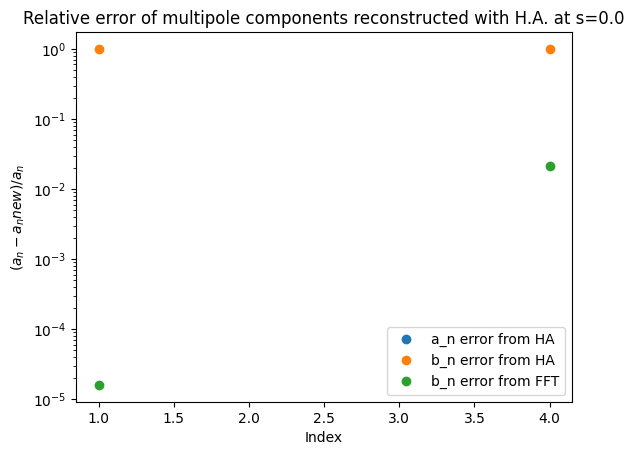

In [14]:
p=4#how many values to plot

plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')
plt.ylabel('$(a_n - a_nnew)/a_n$')
plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bn[:p])/b_coeffs[:p], 'o', label='b_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bnfft[:p])/b_coeffs[:p], 'o', label='b_n error from FFT')
plt.legend()
plt.show()